## Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import TransformerMixin
from imblearn.pipeline import clone


from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NeighbourhoodCleaningRule

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

!pip install shap
import shap
from sklearn.inspection import PartialDependenceDisplay


import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

## Read data and partition it into sets

In [2]:
df = pd.read_csv('bank-full.csv', delimiter=';')
X = df.drop(columns=['y'])
y = df['y'].map({'yes': 1, 'no': 0}) # We map the variable y to transform it into binary

In [3]:
numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
categorical_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome','default', 'housing', 'loan']
cols = X.columns

In [4]:
X_aux, X_test, y_aux, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_aux, y_aux, test_size=0.15, random_state=42, stratify=y_aux)

## Fixed part of the preprocessor

In [5]:
def replace_unknown_with_nan(X):
    X = X.copy()
    X[X == 'unknown'] = np.nan  
    return X

categorical_pipeline = Pipeline([
    ('convert_unknown', FunctionTransformer(replace_unknown_with_nan)),
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat_pipeline', categorical_pipeline, categorical_cols),
        ('numeric', 'passthrough', numeric_cols)
    ],
    remainder='passthrough'
)

## Creation of outlier detection functions

In [6]:
class OutlierDetection_Treatment_MeanStd(TransformerMixin):
    # Class constructor
    def __init__(self, k=1.5, columns=None):
        self.k = k
        self.columns = columns
        self.stats = {}

    # fit method
    def fit(self, X, y=None):
        # Transform X to a DataFrame in case a Numpy array arrives (for Pipeline compatibility)
        order = ['marital', 'contact',   'poutcome','default', 'housing', 'loan', 'job', 'education', 'month','age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
        X = pd.DataFrame(X, columns = order)
        if self.columns == None:
            # If no variables are specified in the constructor, treat all of them
            self.columns = X.columns
            
        for c in self.columns:
            self.stats[c] = {
                "mean": X[c].mean(),
                "std": X[c].std(),
                "median": X[c].median()
            }
        # Return the modified object itself
        return self

    # transform method
    def transform(self, X):
        # Transform X to a DataFrame in case a Numpy array arrives (for Pipeline compatibility)
        X = pd.DataFrame(X)
        # Create a copy of DataFrame X so as not to lose the original data
        X_aux = X.copy() 

        for c in self.columns:
            mean = self.stats[c]["mean"]
            std = self.stats[c]["std"]
            median = self.stats[c]["median"]

            col_dtype = X_aux[c].dtype
            
            # Lower and upper limits to detect outliers
            lower_limit = (mean - self.k * std).astype(col_dtype)
            upper_limit = (mean + self.k * std).astype(col_dtype)
            
            # Values smaller than the lower limit
            smaller = X[c] < lower_limit
            if smaller.any():
                X_aux.loc[smaller, c] = lower_limit
            
            # Values greater than the upper limit
            greater = X[c] > upper_limit
            if greater.any():
                X_aux.loc[greater, c] = upper_limit
            
        # Return the modified DataFrame
        return X_aux
        
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    
    # Method to get the desired hyperparameter values of the model (used by GridSearchCV when displaying the best configuration)
    def get_params(self, deep=True):
        return {"k": self.k, "columns": self.columns}

In [7]:
class OutlierDetection_Treatment_IQR(TransformerMixin):

    # Class constructor
    def __init__(self, k=1.5, columns=None):
        self.k = k
        self.columns = columns
    
    # fit method
    def fit(self, X, y=None):
        # Transform X to a DataFrame in case a Numpy array arrives (for Pipeline compatibility)
        X = pd.DataFrame(X)
        if self.columns == None:
            # If no variables are specified in the constructor, treat all of them
            self.columns = X.columns
        self.stats = X.describe()
        # Return the modified object itself
        return self

    # transform method
    def transform(self, X):
        X = pd.DataFrame(X)
        X_aux = X.copy()

        iqrs = self.stats.loc["75%"] - self.stats.loc["25%"]
        self.lower_limit = self.stats.loc["25%"] - self.k * iqrs
        self.upper_limit = self.stats.loc["75%"] + self.k * iqrs

        for c in self.columns:
            # Get the original dtype of the column
            col_dtype = X_aux[c].dtype

            # Convert the limits to the same type as the column
            lower_lim = self.lower_limit[c].astype(col_dtype)
            upper_lim = self.upper_limit[c].astype(col_dtype)

            # Apply the changes
            smaller = X_aux[c] < lower_lim
            if smaller.any():
                X_aux.loc[smaller, c] = lower_lim

            greater = X_aux[c] > upper_lim
            if greater.any():
                X_aux.loc[greater, c] = upper_lim

        return X_aux
    
    # Method to assign the values of the hyperparameters so that, in this way, 
    # we can apply GridSearchCV on an object of this class
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    
    # Method to get the desired hyperparameter values of the model (used by GridSearchCV when displaying the best configuration)
    def get_params(self, deep=True):
        return {"k": self.k, "columns": self.columns}

### Experiment 1: Optimization of Environments (Dynamic Pipeline)
In this phase, we define the search space for our dynamic pipeline. We will evaluate different techniques for outlier detection, scaling, sampling, and dimensionality reduction, along with specific hyperparameters for each classifier.

Warning: It takes a long time to run (aprox 50 mins) and uses a lot of CPU.

In [8]:
from sklearn.linear_model import LogisticRegression

# 1. BASE TEMPLATE
def create_base_pipeline(classifier):
    return ImbPipeline([
        ('outlier_detector', 'passthrough'),
        ('preprocessor', preprocessor),       # THE ONLY FIXED PART
        ('standardization', 'passthrough'),
        ('sampling', 'passthrough'),
        ('pca', 'passthrough'),
        ('classifier', classifier)
    ])

# 2. DEFINE TECHNIQUES TO CROSS 
outlier_columns = ['age', 'balance', 'day', 'duration', 'campaign']
outlier_options = [
    OutlierDetection_Treatment_IQR(columns=outlier_columns),
    OutlierDetection_Treatment_MeanStd(columns=outlier_columns),
    'passthrough'
]
scaling_options = [StandardScaler(), MinMaxScaler(), 'passthrough']
sampling_options = [SMOTE(random_state=42), NeighbourhoodCleaningRule(), 'passthrough']
pca_options = [PCA(n_components=0.95, random_state=42), 'passthrough']

phase1_results = {}

#### 1. Distance Family: KNN Optimization

In [9]:
print("--- Optimizing KNN ---")

param_grid_knn = {
    'outlier_detector': outlier_options,
    'standardization': scaling_options,
    'sampling': sampling_options,
    'pca': pca_options,
    'classifier__n_neighbors': [3, 5],
    'classifier__weights': ['distance']
}

pipeline_knn = create_base_pipeline(KNeighborsClassifier())

grid_search_knn = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=param_grid_knn,
    scoring='f1',
    cv=3, 
    n_jobs=-1,
    verbose=1
)

grid_search_knn.fit(X_train, y_train)

phase1_results["KNN"] = {
    'best_fscore': grid_search_knn.best_score_,
    'best_pipeline': grid_search_knn.best_estimator_,
    'best_parameters': grid_search_knn.best_params_
}

print(f"\nBest validation F-score (KNN): {grid_search_knn.best_score_:.4f}")
print("\nBest Parameters Chosen:")
for param, value in grid_search_knn.best_params_.items():
    print(f" - {param}: {value}")

--- Optimizing KNN ---
Fitting 3 folds for each of 108 candidates, totalling 324 fits

Best validation F-score (KNN): 0.5070

Best Parameters Chosen:
 - classifier__n_neighbors: 5
 - classifier__weights: distance
 - outlier_detector: passthrough
 - pca: PCA(n_components=0.95, random_state=42)
 - sampling: NeighbourhoodCleaningRule()
 - standardization: StandardScaler()


#### 2. Distance Family: Logistic Regression Optimization

In [10]:
print("--- Optimizing Logistic Regression ---")

param_grid_logreg = {
    'outlier_detector': outlier_options,
    'standardization': scaling_options,
    'sampling': sampling_options,
    'pca': pca_options,
    'classifier__C': [0.01, 1.0], 
    'classifier__class_weight': [None, 'balanced'],
    'classifier__max_iter': [1000] 
}

pipeline_lr = create_base_pipeline(LogisticRegression(random_state=42))

grid_search_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_logreg,
    scoring='f1',
    cv=3, 
    n_jobs=-1,
    verbose=1
)

grid_search_lr.fit(X_train, y_train)

phase1_results["Logistic_Regression"] = {
    'best_fscore': grid_search_lr.best_score_,
    'best_pipeline': grid_search_lr.best_estimator_,
    'best_parameters': grid_search_lr.best_params_
}

print(f"\nBest validation F-score (Logistic Regression): {grid_search_lr.best_score_:.4f}")
print("\nBest Parameters Chosen:")
for param, value in grid_search_lr.best_params_.items():
    print(f" - {param}: {value}")

--- Optimizing Logistic Regression ---
Fitting 3 folds for each of 216 candidates, totalling 648 fits

Best validation F-score (Logistic Regression): 0.5249

Best Parameters Chosen:
 - classifier__C: 1.0
 - classifier__class_weight: None
 - classifier__max_iter: 1000
 - outlier_detector: passthrough
 - pca: PCA(n_components=0.95, random_state=42)
 - sampling: NeighbourhoodCleaningRule()
 - standardization: StandardScaler()


#### 3. Partition Family: Decision Tree Optimization

In [11]:
print("--- Optimizing Decision Tree ---")

param_grid_tree = {
    'outlier_detector': outlier_options,
    'standardization': scaling_options,
    'sampling': sampling_options,
    'pca': pca_options,
    'classifier__max_depth': [5, 20], 
    'classifier__min_samples_split': [10, 100], 
    'classifier__min_samples_leaf': [20] 
}

pipeline_dt = create_base_pipeline(DecisionTreeClassifier(criterion='entropy', random_state=42))

grid_search_dt = GridSearchCV(
    estimator=pipeline_dt,
    param_grid=param_grid_tree,
    scoring='f1',
    cv=3, 
    n_jobs=-1,
    verbose=1
)

grid_search_dt.fit(X_train, y_train)

phase1_results["Decision_Tree"] = {
    'best_fscore': grid_search_dt.best_score_,
    'best_pipeline': grid_search_dt.best_estimator_,
    'best_parameters': grid_search_dt.best_params_
}

print(f"\nBest validation F-score (Decision Tree): {grid_search_dt.best_score_:.4f}")
print("\nBest Parameters Chosen:")
for param, value in grid_search_dt.best_params_.items():
    print(f" - {param}: {value}")

--- Optimizing Decision Tree ---
Fitting 3 folds for each of 216 candidates, totalling 648 fits

Best validation F-score (Decision Tree): 0.5610

Best Parameters Chosen:
 - classifier__max_depth: 20
 - classifier__min_samples_leaf: 20
 - classifier__min_samples_split: 100
 - outlier_detector: <__main__.OutlierDetection_Treatment_IQR object at 0x7b5437974d10>
 - pca: passthrough
 - sampling: NeighbourhoodCleaningRule()
 - standardization: MinMaxScaler()


#### 4. Partition Family: Random Forest Optimization

In [12]:
print("--- Optimizing Random Forest ---")

param_grid_rf = {
    'outlier_detector': outlier_options,
    'standardization': scaling_options,
    'sampling': sampling_options,
    'pca': pca_options,
    'classifier__n_estimators': [300], 
    'classifier__max_depth': [5, None],
    'classifier__min_samples_split': [10, 100] 
}

pipeline_rf = create_base_pipeline(RandomForestClassifier(criterion='entropy', random_state=42))

grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    scoring='f1',
    cv=3, 
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

phase1_results["Random_Forest"] = {
    'best_fscore': grid_search_rf.best_score_,
    'best_pipeline': grid_search_rf.best_estimator_,
    'best_parameters': grid_search_rf.best_params_
}

print(f"\nBest validation F-score (Random Forest): {grid_search_rf.best_score_:.4f}")
print("\nBest Parameters Chosen:")
for param, value in grid_search_rf.best_params_.items():
    print(f" - {param}: {value}")

--- Optimizing Random Forest ---
Fitting 3 folds for each of 216 candidates, totalling 648 fits

Best validation F-score (Random Forest): 0.5898

Best Parameters Chosen:
 - classifier__max_depth: None
 - classifier__min_samples_split: 10
 - classifier__n_estimators: 300
 - outlier_detector: passthrough
 - pca: passthrough
 - sampling: SMOTE(random_state=42)
 - standardization: MinMaxScaler()


## Summary image of experiment 1

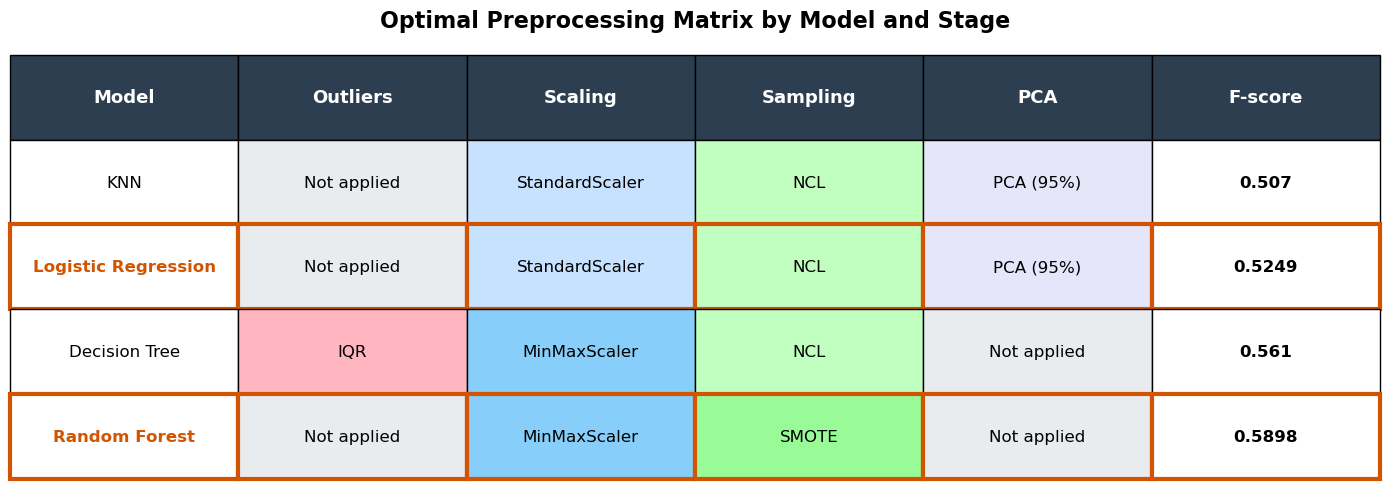

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract and format data from phase1_results
rows = []
for model, data in phase1_results.items():
    params = data['best_parameters']
    
    # Helper function to get the clean name of the technique
    def get_name(obj):
        if isinstance(obj, str): return obj
        if hasattr(obj, '__class__') and obj is not None:
            return obj.__class__.__name__
        return str(obj)

    row = {
        'Model': model.replace('_', ' '),
        'Outliers': get_name(params.get('outlier_detector', 'passthrough')),
        'Scaling': get_name(params.get('standardization', 'passthrough')),
        'Sampling': get_name(params.get('sampling', 'passthrough')),
        'PCA': get_name(params.get('pca', 'passthrough')),
        'F-score': round(data['best_fscore'], 4)
    }
    
    # Clean up long names to fit aesthetically in the matrix
    for col in ['Outliers', 'Scaling', 'Sampling', 'PCA']:
        if row[col] == 'passthrough': 
            row[col] = 'Not applied'
        elif 'IQR' in row[col]:  
            row[col] = 'IQR'
        elif 'MeanStd' in row[col]:
            row[col] = 'MeanStd'
        elif 'Neighbourhood' in row[col]: 
            row[col] = 'NCL'
        elif 'SMOTE' in row[col]:
            row[col] = 'SMOTE'
        elif 'PCA' in row[col] and col == 'PCA': 
            row[col] = 'PCA (95%)'
        
    rows.append(row)

df_plot = pd.DataFrame(rows)

# Mathematically identify the winners (first 2 are distances, last 2 are trees)
idx_distances = df_plot.iloc[0:2]['F-score'].idxmax()
idx_trees = df_plot.iloc[2:4]['F-score'].idxmax()

# Add 1 because in the visual table row 0 is the header
winning_rows = [idx_distances + 1, idx_trees + 1] 

# Configure colors for the visual matrix (Categorical Heatmap)
technique_colors = {
    'Not applied': '#e9ecef',    # gray
    'StandardScaler': '#c6e2ff', # Pastel blue
    'MinMaxScaler': '#87cefa',   # Vivid blue
    'NCL': '#c1ffc1',            # Pastel green
    'SMOTE': '#98fb98',          # Mint green
    'PCA (95%)': '#e6e6fa',      # Pastel purple
    'IQR': '#ffb6c1',            # Light red/Pink
    'MeanStd': '#ff9999'         # red
}

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')

table = ax.table(cellText=df_plot.values,
                 colLabels=df_plot.columns,
                 cellLoc='center',
                 loc='center',
                 bbox=[0, 0, 1, 1]) 

table.auto_set_font_size(False)
table.set_fontsize(12)

# Iterate over the cells to apply formats, colors, and highlight winners
for (row, col), cell in table.get_celld().items():
    if row == 0:
        # Header Style
        cell.set_text_props(weight='bold', color='white', fontsize=13)
        cell.set_facecolor('#2c3e50') # Dark slate blue
    else:
        text = cell.get_text().get_text()
        
        # Color the cell background based on the chosen technique
        cell.set_facecolor(technique_colors.get(text, '#ffffff'))
            
        # Bold format for the F-score column
        if col == 5: 
            cell.set_text_props(weight='bold')
            
        if row in winning_rows:
            cell.set_edgecolor('#d35400') # Thick copper/gold border
            cell.set_linewidth(3)         # Make the outer line thicker
            
            if col == 0:
                cell.set_text_props(weight='bold', color='#d35400')
                cell.get_text().set_text(f"{text}")

plt.title("Optimal Preprocessing Matrix by Model and Stage", fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.show()

# Experiment 2: Transferability (Swap) Matrix
In this phase, we freeze the optimal preprocessing pipelines found in Experiment 1 and force classifiers to run on the "enemy habitat".

Warning: It takes less time than phase 1, but it still takes a long time to run.

In [14]:
print("Starting Phase 2: Setup and Definitions...")

# Hyperparameters updated to match Phase 1 exactly
grid_only = {
    'KNN': {
        'classifier__n_neighbors': [3, 5],
        'classifier__weights': [ 'distance']
    },
    'Logistic_Regression': {
        'classifier__C': [0.01, 1.0],
        'classifier__class_weight': [None, 'balanced'],
        'classifier__max_iter': [1000]
    },
    'Decision_Tree': {
        'classifier__max_depth': [5, 20],
        'classifier__min_samples_split': [10, 100],
        'classifier__min_samples_leaf': [20]
    },
    'Random_Forest': {
        'classifier__n_estimators': [300],
        'classifier__max_depth': [5, None],
        'classifier__min_samples_split': [10, 100]
    }
}

bases = {
    'KNN': KNeighborsClassifier(),
    'Logistic_Regression': LogisticRegression(),
    'Decision_Tree': DecisionTreeClassifier(criterion='entropy', random_state=42),
    'Random_Forest': RandomForestClassifier(criterion='entropy', random_state=42)
}

def evaluate_swap(enemy_pipe, model, grid):
    swap_pipe = clone(enemy_pipe)
    # We keep the preprocessing from the enemy but change the classifier
    swap_pipe.steps[-1] = ('classifier', model)
    gs = GridSearchCV(swap_pipe, grid, scoring='f1', cv=3, n_jobs=-1) 
    gs.fit(X_train, y_train)
    return gs.best_score_

# Data structures to save results for the final matrices
model_names = ['KNN', 'Logistic Regression', 'Decision Tree', 'Random Forest']
natural_scores = []
swap_scores = np.zeros((4, 2))
diff_scores = np.zeros((4, 2))
annot_swap, annot_diff = [], []

Starting Phase 2: Setup and Definitions...


### 1. Evaluating Distance Family in Tree Habitats (KNN)

In [15]:
print("--- Swapping KNN into Tree Habitats ---")
nat_knn = phase1_results['KNN']['best_fscore']
natural_scores.append([nat_knn])

# Enemy pipelines (Trees)
pipe_dt = phase1_results['Decision_Tree']['best_pipeline']
pipe_rf = phase1_results['Random_Forest']['best_pipeline']

# Evaluate
score_knn_vs_dt = evaluate_swap(pipe_dt, bases['KNN'], grid_only['KNN'])
score_knn_vs_rf = evaluate_swap(pipe_rf, bases['KNN'], grid_only['KNN'])

diff_knn_dt = score_knn_vs_dt - nat_knn
diff_knn_rf = score_knn_vs_rf - nat_knn

print(f"KNN original F1: {nat_knn:.4f}")
print(f"KNN in Decision Tree pipeline: {score_knn_vs_dt:.4f} (Drop: {diff_knn_dt:.4f})")
print(f"KNN in Random Forest pipeline: {score_knn_vs_rf:.4f} (Drop: {diff_knn_rf:.4f})")

# Save for plotting (Index 0)
swap_scores[0, :] = [score_knn_vs_dt, score_knn_vs_rf]
diff_scores[0, :] = [diff_knn_dt, diff_knn_rf]
annot_swap.append([f"{score_knn_vs_dt:.4f}\n(vs Tree)", f"{score_knn_vs_rf:.4f}\n(vs RF)"])
annot_diff.append([f"{diff_knn_dt:.4f}\n(vs Tree)", f"{diff_knn_rf:.4f}\n(vs RF)"])

--- Swapping KNN into Tree Habitats ---
KNN original F1: 0.5070
KNN in Decision Tree pipeline: 0.4883 (Drop: -0.0187)
KNN in Random Forest pipeline: 0.4317 (Drop: -0.0753)


### 2. Evaluating Distance Family in Tree Habitats (Logistic Regression)

In [16]:
print("--- Swapping Logistic Regression into Tree Habitats ---")
nat_lr = phase1_results['Logistic_Regression']['best_fscore']
natural_scores.append([nat_lr])

# Enemy pipelines (Trees)
pipe_dt = phase1_results['Decision_Tree']['best_pipeline']
pipe_rf = phase1_results['Random_Forest']['best_pipeline']

# Evaluate
score_lr_vs_dt = evaluate_swap(pipe_dt, bases['Logistic_Regression'], grid_only['Logistic_Regression'])
score_lr_vs_rf = evaluate_swap(pipe_rf, bases['Logistic_Regression'], grid_only['Logistic_Regression'])

diff_lr_dt = score_lr_vs_dt - nat_lr
diff_lr_rf = score_lr_vs_rf - nat_lr

print(f"Logistic Regression original F1: {nat_lr:.4f}")
print(f"Logistic Regression in Decision Tree pipeline: {score_lr_vs_dt:.4f} (Drop: {diff_lr_dt:.4f})")
print(f"Logistic Regression in Random Forest pipeline: {score_lr_vs_rf:.4f} (Drop: {diff_lr_rf:.4f})")

# Save for plotting (Index 1)
swap_scores[1, :] = [score_lr_vs_dt, score_lr_vs_rf]
diff_scores[1, :] = [diff_lr_dt, diff_lr_rf]
annot_swap.append([f"{score_lr_vs_dt:.4f}\n(vs Tree)", f"{score_lr_vs_rf:.4f}\n(vs RF)"])
annot_diff.append([f"{diff_lr_dt:.4f}\n(vs Tree)", f"{diff_lr_rf:.4f}\n(vs RF)"])

--- Swapping Logistic Regression into Tree Habitats ---
Logistic Regression original F1: 0.5249
Logistic Regression in Decision Tree pipeline: 0.5123 (Drop: -0.0127)
Logistic Regression in Random Forest pipeline: 0.5181 (Drop: -0.0069)


### 3. Evaluating Tree Family in Distance Habitats (Decision Tree)

In [17]:
print("--- Swapping Decision Tree into Distance Habitats ---")
nat_dt = phase1_results['Decision_Tree']['best_fscore']
natural_scores.append([nat_dt])

# Enemy pipelines (Distance)
pipe_knn = phase1_results['KNN']['best_pipeline']
pipe_lr = phase1_results['Logistic_Regression']['best_pipeline']

# Evaluate
score_dt_vs_knn = evaluate_swap(pipe_knn, bases['Decision_Tree'], grid_only['Decision_Tree'])
score_dt_vs_lr = evaluate_swap(pipe_lr, bases['Decision_Tree'], grid_only['Decision_Tree'])

diff_dt_knn = score_dt_vs_knn - nat_dt
diff_dt_lr = score_dt_vs_lr - nat_dt

print(f"Decision Tree original F1: {nat_dt:.4f}")
print(f"Decision Tree in KNN pipeline: {score_dt_vs_knn:.4f} (Drop: {diff_dt_knn:.4f})")
print(f"Decision Tree in Logistic Reg pipeline: {score_dt_vs_lr:.4f} (Drop: {diff_dt_lr:.4f})")

# Save for plotting (Index 2)
swap_scores[2, :] = [score_dt_vs_knn, score_dt_vs_lr]
diff_scores[2, :] = [diff_dt_knn, diff_dt_lr]
annot_swap.append([f"{score_dt_vs_knn:.4f}\n(vs KNN)", f"{score_dt_vs_lr:.4f}\n(vs LR)"])
annot_diff.append([f"{diff_dt_knn:.4f}\n(vs KNN)", f"{diff_dt_lr:.4f}\n(vs LR)"])

--- Swapping Decision Tree into Distance Habitats ---
Decision Tree original F1: 0.5610
Decision Tree in KNN pipeline: 0.4989 (Drop: -0.0621)
Decision Tree in Logistic Reg pipeline: 0.4989 (Drop: -0.0621)


### 4. Evaluating Tree Family in Distance Habitats (Random Forest)

In [18]:
print("--- Swapping Random Forest into Distance Habitats ---")
nat_rf = phase1_results['Random_Forest']['best_fscore']
natural_scores.append([nat_rf])

# Enemy pipelines (Distance)
pipe_knn = phase1_results['KNN']['best_pipeline']
pipe_lr = phase1_results['Logistic_Regression']['best_pipeline']

# Evaluate
score_rf_vs_knn = evaluate_swap(pipe_knn, bases['Random_Forest'], grid_only['Random_Forest'])
score_rf_vs_lr = evaluate_swap(pipe_lr, bases['Random_Forest'], grid_only['Random_Forest'])

diff_rf_knn = score_rf_vs_knn - nat_rf
diff_rf_lr = score_rf_vs_lr - nat_rf

print(f"Random Forest original F1: {nat_rf:.4f}")
print(f"Random Forest in KNN pipeline: {score_rf_vs_knn:.4f} (Drop: {diff_rf_knn:.4f})")
print(f"Random Forest in Logistic Reg pipeline: {score_rf_vs_lr:.4f} (Drop: {diff_rf_lr:.4f})")

# Save for plotting (Index 3)
swap_scores[3, :] = [score_rf_vs_knn, score_rf_vs_lr]
diff_scores[3, :] = [diff_rf_knn, diff_rf_lr]
annot_swap.append([f"{score_rf_vs_knn:.4f}\n(vs KNN)", f"{score_rf_vs_lr:.4f}\n(vs LR)"])
annot_diff.append([f"{diff_rf_knn:.4f}\n(vs KNN)", f"{diff_rf_lr:.4f}\n(vs LR)"])

--- Swapping Random Forest into Distance Habitats ---
Random Forest original F1: 0.5898
Random Forest in KNN pipeline: 0.5400 (Drop: -0.0497)
Random Forest in Logistic Reg pipeline: 0.5400 (Drop: -0.0497)


### Visualizing the Total Cross (Swap Matrix)

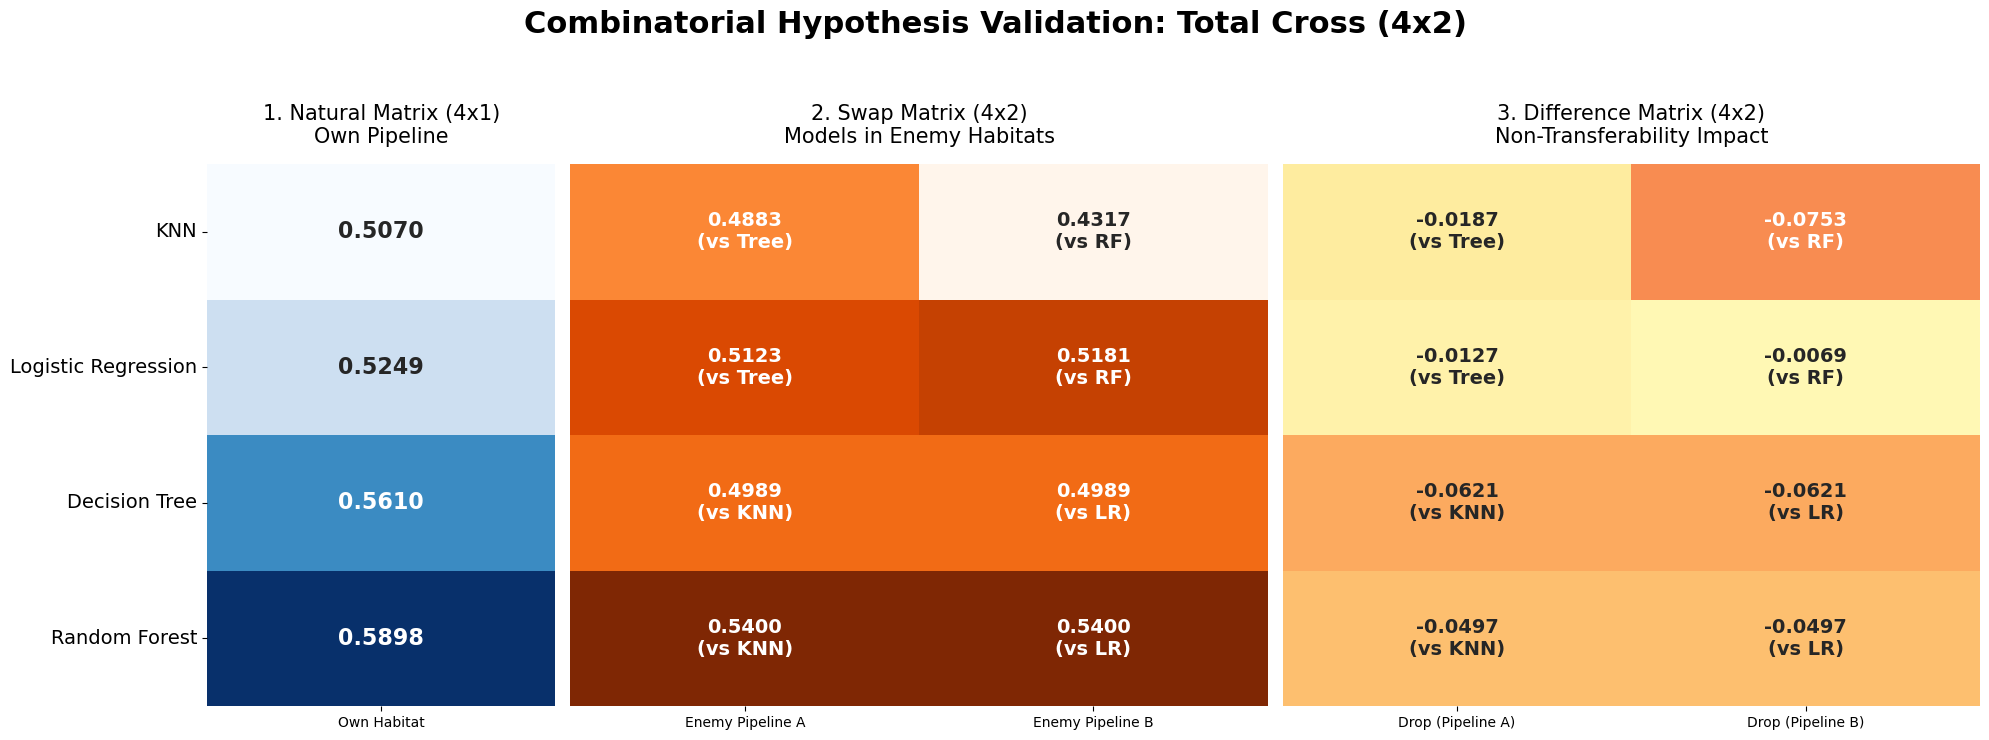

In [19]:
df_nat = pd.DataFrame(natural_scores, index=model_names, columns=['Own Habitat'])
df_swap = pd.DataFrame(swap_scores, index=model_names, columns=['Enemy Pipeline A', 'Enemy Pipeline B'])
df_diff = pd.DataFrame(diff_scores, index=model_names, columns=['Drop (Pipeline A)', 'Drop (Pipeline B)'])

fig, axes = plt.subplots(1, 3, figsize=(20, 7), gridspec_kw={'width_ratios': [1, 2, 2]})

sns.heatmap(df_nat, annot=True, fmt=".4f", cmap="Blues", ax=axes[0], cbar=False, 
            annot_kws={"size": 16, "weight": "bold"})
axes[0].set_title("1. Natural Matrix (4x1)\nOwn Pipeline", fontsize=15, pad=15)
axes[0].tick_params(axis='y', labelsize=14, rotation=0)

sns.heatmap(df_swap, annot=np.array(annot_swap), fmt="", cmap="Oranges", ax=axes[1], cbar=False, 
            annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title("2. Swap Matrix (4x2)\nModels in Enemy Habitats", fontsize=15, pad=15)
axes[1].set_yticks([])

sns.heatmap(df_diff, annot=np.array(annot_diff), fmt="", cmap="RdYlGn", center=0, vmax=0, vmin=-0.15, 
            ax=axes[2], cbar=False, annot_kws={"size": 14, "weight": "bold"})
axes[2].set_title("3. Difference Matrix (4x2)\nNon-Transferability Impact", fontsize=15, pad=15)
axes[2].set_yticks([])

plt.suptitle("Combinatorial Hypothesis Validation: Total Cross (4x2)", fontsize=22, weight='bold', y=1.05)
plt.tight_layout()
plt.show()

## SHAP values

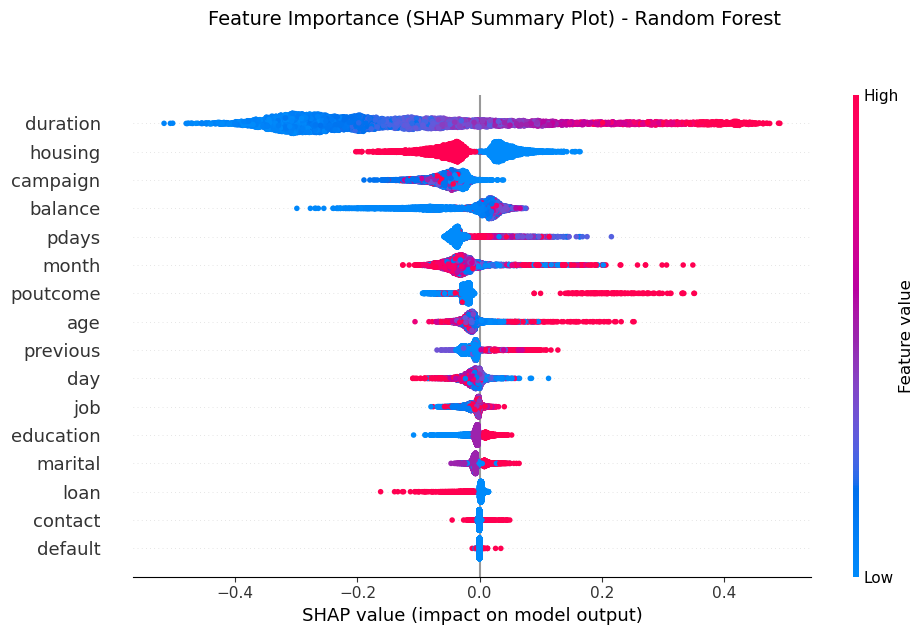

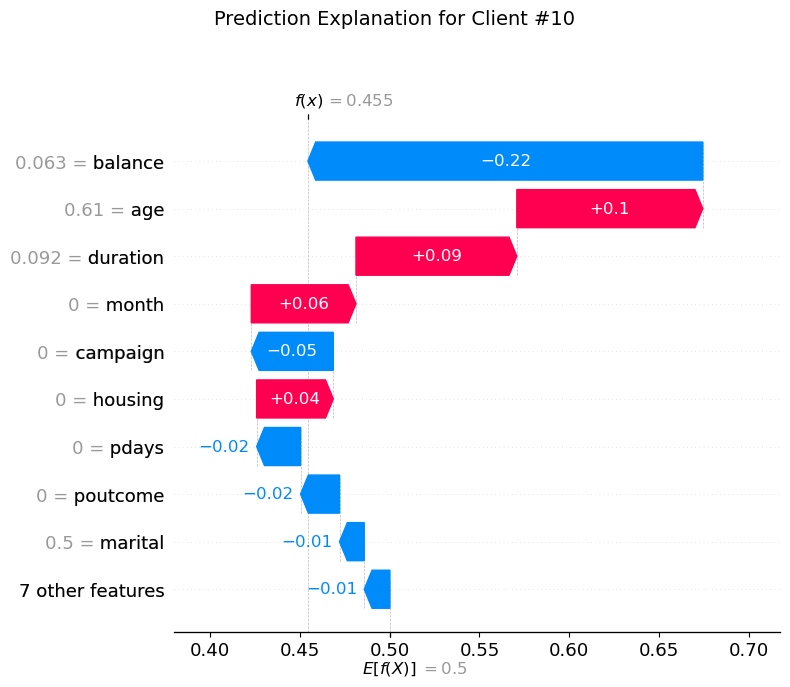

In [20]:
# Extract the winning Random Forest pipeline
pipe_rf = phase1_results["Random_Forest"]['best_pipeline']

# Separate the preprocessing from the classifier model
transformer_rf = pipe_rf[:-1]
model_rf = pipe_rf.named_steps['classifier']

X_val_transformed = transformer_rf.transform(X_val)
feature_names = categorical_cols + numeric_cols

# We convert the array to a DataFrame so SHAP can read the names
X_val_shap = pd.DataFrame(X_val_transformed, columns=feature_names)


# INSTANTIATE SHAP (TreeExplainer)
explainer = shap.TreeExplainer(model_rf)
shap_values = explainer.shap_values(X_val_shap)

# SHAP version compatibility for binary classification
if isinstance(shap_values, list):
    shap_values_positive = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_positive = shap_values[:, :, 1]
else:
    shap_values_positive = shap_values
    

# PLOT 1: Global Summary (Summary Plot)

shap.summary_plot(shap_values_positive, X_val_shap, show=False, plot_size=(10, 6))
fig1 = plt.gcf()
fig1.suptitle("Feature Importance (SHAP Summary Plot) - Random Forest", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# PLOT 2: Local Explanation (Waterfall Plot) 
client_index = 10

# We create the Explanation object required by modern versions of SHAP
expl_obj = shap.Explanation(
    values=shap_values_positive[client_index], 
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value, 
    data=X_val_shap.iloc[client_index].values, 
    feature_names=feature_names
)

shap.waterfall_plot(expl_obj, show=False)
fig2 = plt.gcf()
fig2.suptitle(f"Prediction Explanation for Client #{client_index}", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()


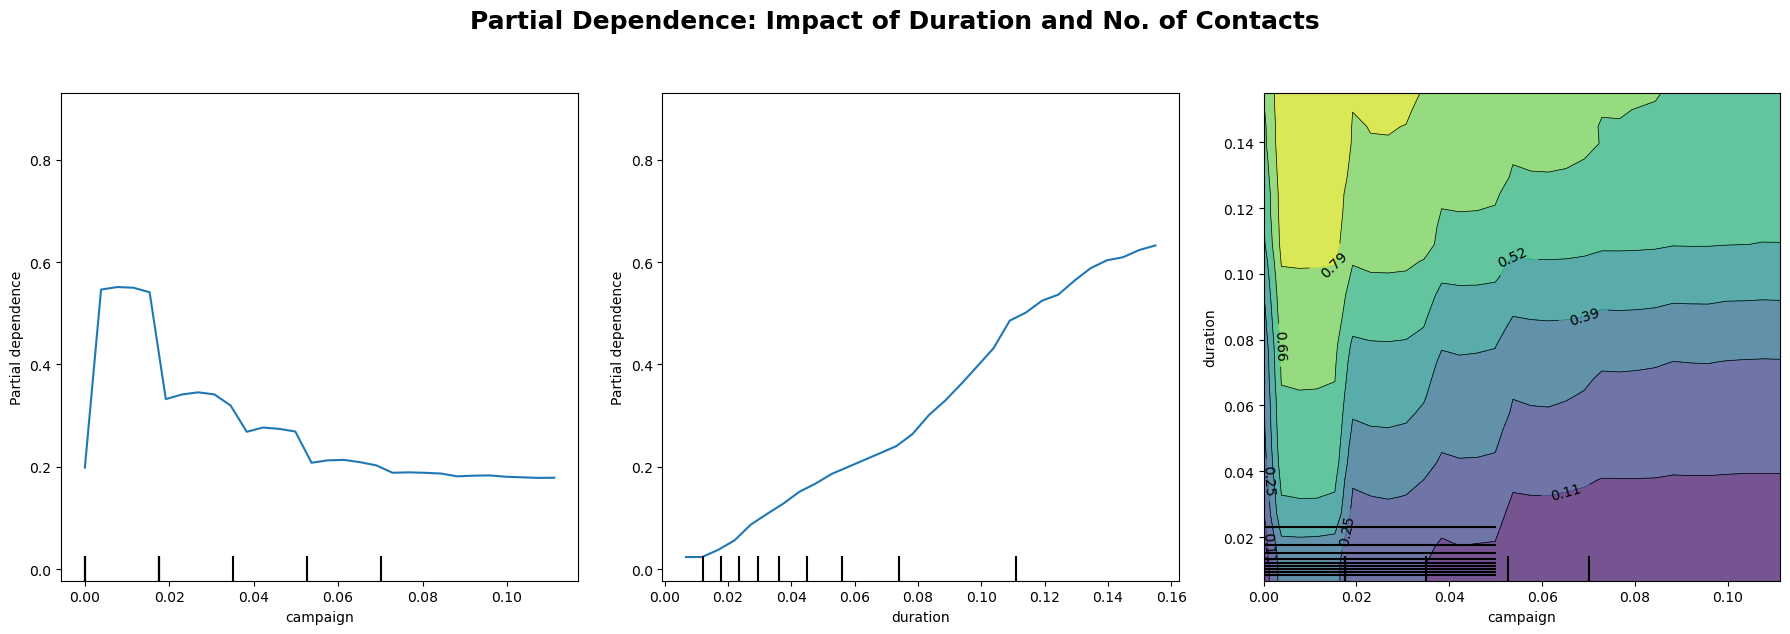

In [21]:
import matplotlib.pyplot as plt
import warnings

fig, ax = plt.subplots(ncols=3, figsize=(18, 6))

# We use a warning filter to silence Scikit-Learn's complaints
# about the original model being trained without feature names.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    
    PartialDependenceDisplay.from_estimator(
        estimator=model_rf,           # The isolated Random Forest classifier
        X=X_val_shap,                 # The validation data already processed and with names
        features=['campaign', 'duration', ['campaign', 'duration']], # Variables to analyze
        grid_resolution=30,           # Grid resolution
        target=1,                     # Target the positive class (Accepts the deposit = 1)
        ax=ax,                        # Pass the 3 axes we have created
        n_jobs=-1                     # Parallelize for more speed
    )

# Aesthetic adjustments to look perfect in the report
fig.suptitle("Partial Dependence: Impact of Duration and No. of Contacts", 
             fontsize=18, weight='bold', y=1.05)


plt.tight_layout()
plt.show()